# Living Cells

We start with an introduction into the basics of living cells.

## Coding setup

We will stick to Python 3 code that can be run stand-alone at your computer whenever possible.
When running the code locally on your computer, we suggest to use a virtual environment.
We will install several libraries and a virtual environment helps to not interfere with the system's Python libraries.

For [venv](https://docs.python.org/3/library/venv.html) this is done by running this in the directory that will be used for the lecture:
```sh
python -m venv venv
. ./venv/bin/activate
```

Next let's load some libraries we will need for the course.

In [3]:
# in case you need to install a library run a command like:
# %pip install numpy
# %pip install matplotlib
# %pip install mobspy

# imports
import numpy as np
import matplotlib.pyplot as plt

# configure notebook figures
# remove it in case you run it as stand-alone code
%matplotlib inline

## Computing cell

A cell is a **computing device**: it senses molecular inputs, processes them through a network of biochemical reactions, and produces outputs that determine its behavior: growth, motion, gene expression, division.
This computation has been running, and refined by natural selection, for roughly four billion years.

![Timeline of life on Earth (from Wikipedia)](figs/life_timeline_wiki.png){width="60%"}

Cells span a wide range of scales: a bacterium such as _E. coli_ occupies about $1\,\mu\text{m}^3 = 1\,\text{fL}$ ([bionumbers](https://bionumbers.hms.harvard.edu/bionumber.aspx?id=100004)), a microalga such as _Chlamydomonas reinhardtii_ roughly $270\,\mu\text{m}^3$ ([bionumber](https://bionumbers.hms.harvard.edu/bionumber.aspx?s=n&v=2&id=110530)), and a typical human cell roughly $500$–$4{,}000\,\mu\text{m}^3$ ([bionumbers](https://book.bionumbers.org/how-big-is-a-human-cell/)). Within each, thousands of molecular species interact through reactions that sense, integrate, and relay signals.

The figure below compares these volumes under the simplifying assumption of cells being balls.


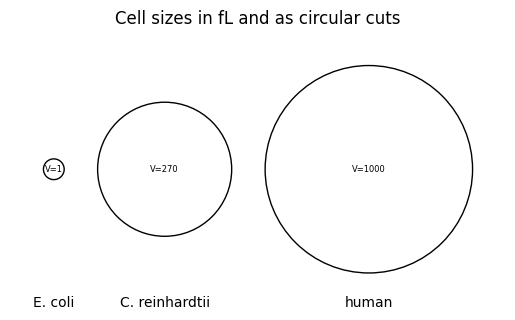

In [4]:
volumes = [1, 270, 1000]
names = ["E. coli", "C. reinhardtii", "human"]
radii = [(3*v/(4*np.pi))**(1/3) for v in volumes]

gap = 2
x = [0]
for i in range(1, len(radii)):
    x.append(x[-1] + radii[i-1] + radii[i] + gap)

fig, ax = plt.subplots()

for xi, r, v, name in zip(x, radii, volumes, names):
    ax.add_patch(plt.Circle((xi, 0), r, fill=False))
    ax.text(xi, 0, f"V={v}", ha="center", va="center", fontsize=6)
    ax.text(xi, -8, name, ha="center", va="center", fontsize=10)

plt.title("Cell sizes in fL and as circular cuts")

ax.set_aspect("equal")
ax.set_xlim(x[0] - radii[0] - gap, x[-1] + radii[-1] + gap)
ax.set_ylim(-max(radii) - gap, max(radii) + gap)
ax.axis("off")

plt.show()

Cells have different means to acquire inputs, perform computations, and generate outputs.
These include biochemical mechanisms to:
- **sense** their environment, including nutrient gradients, toxins, and signaling molecules
- **process** the stimuli through cascading networks of proteins, signaling molecules, metabolites, and nucleic acids
- **act** by altering growth rate, secreting molecules, or moving toward or away from a signal

The computational substrate is chemistry rather than silicon, and the relevant timescales are set by molecular collision rates.
Yet the problems solved, from reliable signal detection under molecular noise to robust decision-making with imprecise components and distributed coordination across cell populations, remain ones that challenge our best engineered systems.

Understanding how cells compute, and learning to engineer that computation, is what this course is about.

### Models
To describe (aspects of) a cell's behavior models on different levels of abstraction have been used. During the course we will discuss some of these. An example is Chemical Reaction Networks (CRNs) that describe the evolution of species in a cell via reactions that occur among the species.
Reactions modify, generate, and consume other species.
While such a (chemically inspired) model may seem mostly relevant at a molecular level, we will see that one can also use it at more abstract levels. A core difference there is that we often drop the assumption that mass is preserved in the reactions.
More on this later in the course.

### A model organism: the bacterium _Escherichia coli_ (_E. coli_)
While many of the concepts covered in the course are general to a wide class of cells, we will
often refer to [_E. coli_](https://en.wikipedia.org/wiki/Escherichia_coli) as an example.
_E. coli_ is a gram negative bacterium. It has an inner and outer membrane.

![E.coli (from CDC, https://phil.cdc.gov)](https://phil.cdc.gov/PHIL_Images/10071/10071_lores.jpg)

Bacteria belong to the prokaryotes, which is Greek for "before kernel"; they do not possess of a nucleus such as mammalian cells of humans.

The shape of an is _E. coli_ approximately cylindrical with round caps (rod shaped) with a radius of $0.5\mu$ and length of $2\mu m$. Their volume of about $1 \mu m^3$, or equivalently, $10^{-15} L = 1fL$.
_E. coli_ cultures [grow by cell division](https://www.youtube.com/watch?v=_5bGPa-QXV4) with a rate depending on several factors like strain, temperature, and available nutrients in the growth medium. During fast growth cells duplicate about every 20 min.

Below is a schematic of its membranes from the inside of the cell (cytoplasm, bottom in the figure) to the outside (top in the figure).

![E.coli (from wikimedia, https://en.wikipedia.org/wiki/Gram-negative_bacteria)](https://upload.wikimedia.org/wikipedia/commons/thumb/8/8b/Gram_negative_cell_wall.svg/1920px-Gram_negative_cell_wall.svg.png)

Recently microscopy has made significant advances in capturing high-resolution images of parts of cells. One such image you can find in [Matias, Valério RF, et al., J. of Bacteriology, 2020](https://journals.asm.org/doi/10.1128/JB.185.20.6112-6118.2003#pill-references) Fig.4. of the paper where membranes are nicely visible.

### Genome

The genome of _E. coli_ is a double stranded circular DNA and varies considerably by strain.
For MG1655 (a K-12 substrain) it is 4,641,652 bp long and can be found in the
[ncbh database](https://www.ncbi.nlm.nih.gov/nuccore/U00096).
It comprises of 4,000 to 5,000 genes. The following figure shows the annotated genomes with currently known genes in 2026.

![E.coli genome (from https://ecocyc.org/genbro/genbro.shtml?orgid=ECOLI&replicon=COLI-K12)](figs/poster-genome-Escherichia-coli-K-12-substr-MG1655.jpg)


**Gene.** A gene is a sequence of DNA that is transcribed. Not necessarily all genes are translated (result in proteins though) and postprocessing may happen on several layers. Genes often occur in clusters with common control elements. These sequences including genes and control elements are called **operons**.
They are particularly important from a computational perspective and we will discuss them in detail throughout the course.




### Crowded volume

The cytoplasm of a cell should be imagined as a crowded space in contrast to molecules freely floating around.
To get an impression how densely packed it is, see this
[simulation of the cytoplasm of _E. coli_ during 15ms by McGuffee and Elcock](http://cellimagelibrary.org/images/28234).

A fascinating, already cleared up but still crowded, interactive visualization can be found at [cellsignal.com](https://media.cellsignal.com/www/html/science/landscapes/adhesion/adhesion.html#acHero_86)


![crowded cell (from media.cellsignal.com)](figs/cellsignal_cell.png)


### The central dogma

**Central dogma.** The flow of genetic information in a cell was summarized by Francis Crick in 1958. DNA stores the heritable sequence information. The universal flows are:

- **Replication**: DNA $\to$ DNA (genome copied before division)
- **Transcription**: DNA $\to$ RNA (a gene is transcribed into messenger RNA)
- **Translation**: RNA $\to$ protein (mRNA translated into amino acid sequence)

Two additional flows occur in specific organisms but are not happening in all cells:
- **Reverse transcription**: RNA $\to$ DNA (retroviruses such as HIV)
- **RNA replication**: RNA $\to$ RNA (RNA viruses)

![Central dogma of molecular biology (from Wikipedia)](https://upload.wikimedia.org/wikipedia/commons/d/dd/Extended_Central_Dogma_with_Enzymes.jpg)

Sequence information does not flow from protein back to nucleic acid under any known natural conditions.



### DNA

A **nucleotide** is the monomer, the basic building brick, of DNA: a phosphate group, a 2′-deoxyribose sugar, and one of four nitrogenous bases: adenine (A), thymine (T), guanine (G), cytosine (C). A and G are purines (two-ring); T and C are pyrimidines (one-ring).


![DNA composition (from Wikipedia)](https://upload.wikimedia.org/wikipedia/commons/thumb/1/19/Phosphate_backbone.jpg/960px-Phosphate_backbone.jpg){width="70%"}

DNA is a **double helix** of two antiparallel polynucleotide strands (Watson and Crick, 1953). The strands are held together by Watson-Crick base pairing: A pairs with T via two hydrogen bonds, G pairs with C via three and thus binds stronger. The higher the G-C content in a DNA segment, the more thermally stable the duplex.

![DNA double helix with labeled structural features (from Wikipedia)](https://upload.wikimedia.org/wikipedia/commons/thumb/4/4c/DNA_Structure%2BKey%2BLabelled.pn_NoBB.png/960px-DNA_Structure%2BKey%2BLabelled.pn_NoBB.png){width="70%"}

Here we see the bonds in greater detail.

<div style="display:flex; justify-content:center; gap:30px; margin:20px 0;">
  ![A–T: 2 hydrogen bonds](https://upload.wikimedia.org/wikipedia/commons/thumb/d/db/Base_pair_AT.svg/1920px-Base_pair_AT.svg.png){width="45%"}
  ![G–C: 3 hydrogen bonds](https://upload.wikimedia.org/wikipedia/commons/thumb/6/64/Base_pair_GC.svg/1920px-Base_pair_GC.svg.png){width="45%"}
</div>

**Direction.** Each strand has chemical polarity: the 5′ end carries a free phosphate on the 5′ carbon of the sugar; the 3′ end carries a free hydroxyl on the 3′ carbon. The two strands of a duplex are antiparallel: one runs 5′ $\to$ 3′ while its complement runs 3′ $\to$ 5′.

**Plus and minus strands.** By convention the (+) strand, also called the sense or coding strand, has the same sequence as the mRNA (with T in place of U). The (−) strand, the antisense or template strand, is its complement and serves as the template for the RNA polymerase (RNAP) during transcription. Which strand is (+) depends on the gene: on a circular bacterial chromosome, different genes use different strands as their template.

![DNA plus and minus strands](figs/dna.svg){width="60%"}


### DNA Synthesis

DNA strands can only be synthesized in the direction 5' $\to$ 3'. This is done when the genome is copied.
The strand that is read is read in the direction 3' $\to$ 5' to create a 5' $\to$ 3' copy.
Synthesis is performed by the DNA-bound DNA polymerase, or short, DNA polymerase.

DNA replication starts from the `oriC` site in both directions along the circular genome in _E. coli_.
The **DNA helicase** creates a so-called moving replication fork so that the DNA polymerase can access the strands for replication.

![DNA replication fork (from Wikipedia)](https://upload.wikimedia.org/wikipedia/commons/thumb/0/0a/Replication_fork.svg/3840px-Replication_fork.svg.png){width="60%"}

As we see here the lagging strand cannot be synthesized continuously since synthesis can be only 5' $\to$ 3'.
The short initial starts are from RNA that is synthesized via the **Primase enzyme**.

> Side note: Speed. _E. coli_ can synthesize DNA at 1000 $\text{nt}\,\text{s}^{-1}$. This is much faster than human cells that have a speed of 50 $\text{nt}\,\text{s}^{-1}$.
> How long does it take to replicate the whole _E. coli_ genome?
> At a size of 4.6 Mbp and the fact that the genome is replicated form both sides, we obtain a duration of
> $$ \frac{4.6\, \text{Mbp} \cdot \frac{1}{2}}{1000\, \text{bp}\,\text{s}^{-1}} \approx 40 \, \text{min} .$$

Several such replications must thus be ongoing during growth of an _E. coli_ that divides every 20 min.
The gens close to the `oriC` thus exist in multiples.




### RNA

RNA nucleotides differ from DNA in two respects: the sugar is ribose (with a 2′-OH group) rather than deoxyribose, and uracil (U) replaces thymine (T). U base-pairs with A, just as T does.

**Direction.** RNA is synthesized and read 5′ to 3′, the same convention as DNA. During transcription, RNAP moves along the template strand 3′ $\to$ 5′ and builds the transcript 5′ $\to$ 3′.

> Side note: Speed. _E. coli_ can transcribe at about 40-80 $\text{nt}\,\text{s}^{-1}$. This is again faster than human cells that have a speed of 6-70 $\text{nt}\,\text{s}^{-1}$.

RNA is typically **single-stranded**, but extensive intramolecular base pairing creates secondary structures (stems, loops, pseudoknots) that are critical for function. The main functional classes in bacteria are:

| Class | Function |
|-------|----------|
| mRNA | carries coding sequence from gene to ribosome |
| tRNA | adaptor molecule linking codon to amino acid |
| rRNA | structural and catalytic core of the ribosome |
| sRNA | small regulatory RNA, often by base-pairing with mRNA |

In eukaryotes, pre-mRNA undergoes further processing (5′ capping, splicing of introns, 3′ polyadenylation) before export from the nucleus. Bacteria lack these steps: the primary transcript often is the mature mRNA.

### Transcription

The enzyme responsible for transcription is **RNA polymerase** (RNAP or simply R). In bacteria, the catalytic core (subunit composition α₂ββ′ω) cannot on its own locate where on the chromosome to begin. The **σ (sigma) factor** is a dissociable subunit that associates with the core to form the **holoenzyme** (α₂ββ′ωσ also written as Rσ). The sigma factor recognizes the **promoter**: a pair of conserved sequence motifs at positions −35 and −10 relative to the transcription start site. After binding, and being in the so-called **closed complex**, the holoenzyme unwinds roughly DNA locally by favorable energetic binding conditions to form the **open complex**, allowing the template strand to enter the active site of the holoenzyme.

Transcription then proceeds in three stages:
1. **Initiation**: holoenzyme binds promoter, transitioning from the closed complex to the open complex. It starts transcribing the DNA, but may easily fall off and interrupt during the first few codons.
Sigma dissociates once elongation is underway.

2. **Elongation**: RNAP moves along the template strand (3′ $\to $ 5′), synthesizing mRNA 5′ $\to$ 3′ at roughly
$40-80\;\text{nt}\,\text{s}^{-1}$ in _E. coli_.

3. **Termination**: RNAP stalls at a terminator sequence and releases the mRNA transcript.

_E. coli_ encodes seven sigma factors. The housekeeping factor $\sigma^{70}$ directs transcription of most genes during exponential growth. Alternative sigma factors (e.g., $\sigma^{32}$) redirect RNAP to stress-response genes, giving the cell a simple mechanism for large-scale transcriptional reprogramming. This is a recurring design motif we will encounter throughout the course.

![From DNA to mRNA: transcription overview (from www.sciencefacts.net).](https://www.sciencefacts.net/wp-content/uploads/2022/08/Transcription-in-Prokaryotes.jpg){width="70%"}


### Translation

The mRNA is decoded by the **ribosome**, a large ribonucleoprotein assembly. In bacteria it consists of a 30S small subunit and a 50S large subunit (together: 70S). The small subunit positions itself on the mRNA via the **Shine-Dalgarno sequence**, a purine-rich stretch about 5-10 nt upstream of the start codon (AUG) that base-pairs with the 3′ end of 16S rRNA.

During elongation, **aminoacyl-tRNAs** enter the A-site, each matching the codon by anticodon base-pairing. The large subunit catalyzes peptide bond formation, the ribosome translocates by one codon, and the growing polypeptide is extended at roughly 15-20 amino acids $\text{s}^{-1}$.
Translation ends at a stop codon (UAA, UAG, or UGA), triggering release of the polypeptide.

![Translation at the ribosome (from Wikipedia)](https://upload.wikimedia.org/wikipedia/commons/9/91/Prokaryotic_Translation_Initiation.png){width="70%"}

In bacteria, transcription and translation are **spatially coupled**: ribosomes begin translating the 5′ end of an mRNA while RNAP is still synthesizing the 3′ end. This co-transcriptional translation is absent in eukaryotes, where transcription occurs in the nucleus and mRNA must be exported before cytoplasmic translation can begin.

## Pathways in _E. coli_

Reactions are typically grouped together into pathways, that describe reactions for a certain cell function. 
Examples are the modification of molecules by enzymes along _metabolic pathways_ as well as transcription and translation in _genetic pathways_.
An overview of reactions grouped into pathways is shown in the figure below.
An interactive schematic is available [here by ecocyc](https://ecocyc.org/overviewsWeb/celOv.shtml?orgid=ECOLI) and lists of pathways available, e.g., by [biocyc](https://biocyc.org/ECOLI/class-tree?object=Pathways) and
[kegg](https://www.genome.jp/kegg/pathway.html#cellular).

![schematic of E. coli pathways (from ecocyc, https://ecocyc.org/overviewsWeb/celOv.shtml?orgid=ECOLI)](figs/ecoli_reactions.png)

Below is an excerpt of reactions from a genetic pathway that includes the expression of the `lacI` gene.
See [here](https://ecocyc.org/gene?orgid=ECOLI&id=MONOMER0-159) for an interactive version.
These reactions will play a role later on in the course.

![lacI gene in pathways (from ecocyc)](figs/lacI.png)




---
**License & Attribution**: This page is adapted from material by [Michael Elowitz and Justin Bois](https://biocircuits.github.io/) (© 2021–2025), licensed under [CC BY-NC-SA 4.0](https://creativecommons.org/licenses/by-nc-sa/4.0/).